In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import sklearn
import statsmodels
import xgboost as xgb
import shap
from arch import arch_model

In [88]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller
from scipy.stats import t



In [7]:
#Upload datasets

sp500 = pd.read_csv("SP 500 HP 2019-2024 v2.csv")
vix = pd.read_csv("VIX HP 2019-2024.csv")
skew = pd.read_csv("SKEW Index 2019-2024.csv")
cboe = pd.read_csv("CBOE 2019-2024.csv")
us3m = pd.read_csv("Risk-free rate USGG3M 3-month treasury bill 2019-2024.csv")
us2y = pd.read_csv("Risk-free rate USGG2YR treasury bill 2019-2024.csv")
us10y = pd.read_csv("Risk-free rate USGG10YR treasury bill 2019-2024.csv")
sofr = pd.read_csv("Risk-free rate SOFR rate 2019-2024.csv")

dxy = pd.read_csv("Dollar Index 2019-2024.csv")


In [8]:
#Date format
sp500['Date'] = pd.to_datetime(sp500['Date'], dayfirst = True)
vix['Date'] = pd.to_datetime(vix['Date'], dayfirst=True)
skew['Date'] = pd.to_datetime(skew['Date'], dayfirst=True)
cboe['Date'] = pd.to_datetime(cboe['Date'], dayfirst=True)
us3m['Date'] = pd.to_datetime(us3m['Date'], dayfirst=True)
us2y['Date'] = pd.to_datetime(us2y['Date'], dayfirst=True)
us10y['Date'] = pd.to_datetime(us10y['Date'], dayfirst=True)
sofr['Date'] = pd.to_datetime(sofr['Date'], dayfirst=True)
dxy['Date'] = pd.to_datetime(dxy['Date'], dayfirst=True)

In [9]:
#Renaming
vix = vix.rename(columns={'Last Price': 'lastp_vix'})
skew = skew.rename(columns={'Last Price': 'lastp_skew'})
us3m = us3m.rename(columns={'Last Price': 'lastp_us3m'})
us10y = us10y.rename(columns={'Last Price': 'lastp_us10y'})
sofr = sofr.rename(columns={'Last Price': 'lastp_sofr'})
dxy = dxy.rename(columns={'Last Price': 'lastp_dxy'})

In [10]:
# Date Cleaning

def prepare_df(df, date_col="Date", value_col=None, new_name=None):
    df = df.copy()
    
    # Convert to Date
    df[date_col] = pd.to_datetime(df[date_col])
    
    # Ordering
    df = df.sort_values(date_col)
    
    # Specific column
    if value_col is not None:
        df = df[[date_col, value_col]]
        df = df.rename(columns={value_col: new_name})
    
    return df

In [11]:
print(sp500.columns)

Index(['Date', 'Last Price', 'Open Price', 'High Price', 'Low Price', 'Volume',
       'Dividend 12 Month Yld - Gross', '\tHist. Put Implied Volatility',
       '\tTotal Put Open Interest', '\tTotal Put Volume',
       '\t3 Month Put Implied Volatility', '\t12 Month Put Implied Volatility',
       '\t30 Day Put Implied Volatility', '\t30 Day Put Implied Volatility.1',
       '\tPut Call Volume Ratio - Current Day',
       '\tHist. Call Implied Volatility', '\t3 Month Call Implied Volatility',
       '\tTotal Call Open Interest', '\t30 Day Call Implied Volatility',
       '\tTotal Call Volume', '\t6 Month Call Implied Volatility'],
      dtype='str')


In [12]:
#Clean tab 

sp500.columns = sp500.columns.str.replace('\t', '', regex=False).str.strip()

In [13]:
print(sp500.columns)

Index(['Date', 'Last Price', 'Open Price', 'High Price', 'Low Price', 'Volume',
       'Dividend 12 Month Yld - Gross', 'Hist. Put Implied Volatility',
       'Total Put Open Interest', 'Total Put Volume',
       '3 Month Put Implied Volatility', '12 Month Put Implied Volatility',
       '30 Day Put Implied Volatility', '30 Day Put Implied Volatility.1',
       'Put Call Volume Ratio - Current Day', 'Hist. Call Implied Volatility',
       '3 Month Call Implied Volatility', 'Total Call Open Interest',
       '30 Day Call Implied Volatility', 'Total Call Volume',
       '6 Month Call Implied Volatility'],
      dtype='str')


In [14]:
# Cleaning SP500

sp500 = sp500.rename(columns={
    'Last Price': 'last_price_sp500',
    'Volume': 'volume_sp500',
    'Put Call Volume Ratio - Current Day': 'put_call_volume_sp500',
    'Hist. Put Implied Volatility': 'put_iv_hist_sp500',
    'Hist. Call Implied Volatility': 'call_iv_hist_sp500',
    '30 Day Put Implied Volatility': 'iv_30d_sp500',
    '30 Day Call Implied Volatility': 'call_iv_30d_sp500'
})
#sp500 = sp500.drop(columns=['30 Day Put Implied Volatility.1'])

# Selection
sp500 = sp500[[
    'Date',
    'last_price_sp500',
    'volume_sp500',
    'put_call_volume_sp500',
    'iv_30d_sp500'
]]

In [15]:
# Datasets selection
vix = vix[['Date', 'lastp_vix']]
skew = skew[['Date', 'lastp_skew']]
us3m = us3m[['Date', 'lastp_us3m']]
us10y = us10y[['Date', 'lastp_us10y']]
sofr = sofr[['Date', 'lastp_sofr']]
dxy = dxy[['Date', 'lastp_dxy']]

In [16]:
# Datasets merging
df = sp500.copy()

dfs = [vix, skew, us3m, us10y, sofr, dxy]

for d in dfs:
    df = pd.merge(df, d, on='Date', how='inner')

In [17]:
# Dataset validation
print(df.shape)
print(df.isna().sum())
print(df.head())

(1497, 11)
Date                     0
last_price_sp500         0
volume_sp500             0
put_call_volume_sp500    0
iv_30d_sp500             0
lastp_vix                0
lastp_skew               0
lastp_us3m               0
lastp_us10y              0
lastp_sofr               0
lastp_dxy                0
dtype: int64
        Date  last_price_sp500  volume_sp500  put_call_volume_sp500  \
0 2024-12-31           5881.63   572261504.0                   1.18   
1 2024-12-30           5906.94   576929024.0                   1.20   
2 2024-12-27           5970.84   584265408.0                   1.26   
3 2024-12-26           6037.59   438611808.0                   1.12   
4 2024-12-24           6040.04   329662272.0                   1.57   

   iv_30d_sp500  lastp_vix  lastp_skew  lastp_us3m  lastp_us10y  lastp_sofr  \
0         14.11      17.35      169.16      4.3144       4.5690        4.49   
1         14.10      17.40      161.08      4.2782       4.5327        4.37   
2         12.68

In [18]:
# X day return variables

df['ret_1d'] = np.log(df['last_price_sp500'] / df['last_price_sp500'].shift(1))
df['ret_5d'] = np.log(df['last_price_sp500'] / df['last_price_sp500'].shift(5))
df['ret_10d'] = np.log(df['last_price_sp500'] / df['last_price_sp500'].shift(10))

df['ret_5d_fwd'] = np.log(df['last_price_sp500'].shift(-5) / df['last_price_sp500'])

df['yield_slope'] = df['lastp_us10y'] - df['lastp_us3m']


In [19]:
# Baseline features Amoanu
df["price_lag1"] = df["last_price_sp500"].shift(1)
df["price_lag2"] = df["last_price_sp500"].shift(2)
df["price_lag3"] = df["last_price_sp500"].shift(3)

df["rolling_mean_5"] = df["last_price_sp500"].shift(1).rolling(5).mean()
df["rolling_std_5"]  = df["last_price_sp500"].shift(1).rolling(5).std()

df["rolling_mean_10"] = df["last_price_sp500"].shift(1).rolling(10).mean()
df["rolling_std_10"]  = df["last_price_sp500"].shift(1).rolling(10).std()

In [20]:
# GARCH Vol Thesis

df = df.sort_values('Date').copy()

garch_data = df['ret_1d'].dropna() * 100

garch_model = arch_model(garch_data, mean = 'Constant', vol='GARCH', p=1, q=1, rescale=False)
garch_fit = garch_model.fit(disp = 'off')

df.loc[garch_data.index, 'garch_vol'] = garch_fit.conditional_volatility / 100

df['garch_vol'] = df['garch_vol'].shift(1)

In [21]:
# Dataset validation 
print(df.shape)
print(df.isna().sum())
print(df.head())

(1497, 24)
Date                      0
last_price_sp500          0
volume_sp500              0
put_call_volume_sp500     0
iv_30d_sp500              0
lastp_vix                 0
lastp_skew                0
lastp_us3m                0
lastp_us10y               0
lastp_sofr                0
lastp_dxy                 0
ret_1d                    1
ret_5d                    5
ret_10d                  10
ret_5d_fwd                5
yield_slope               0
price_lag1                1
price_lag2                2
price_lag3                3
rolling_mean_5            5
rolling_std_5             5
rolling_mean_10          10
rolling_std_10           10
garch_vol                 1
dtype: int64
           Date  last_price_sp500  volume_sp500  put_call_volume_sp500  \
1496 2019-01-02           2510.03   637584256.0                   1.55   
1495 2019-01-03           2447.89   762962304.0                   1.76   
1494 2019-01-04           2531.94   774811392.0                   1.42   
1493 201

In [22]:
# Dataset correction
df = df.dropna()
print("DF Thesis")
print(df.columns)

DF Thesis
Index(['Date', 'last_price_sp500', 'volume_sp500', 'put_call_volume_sp500',
       'iv_30d_sp500', 'lastp_vix', 'lastp_skew', 'lastp_us3m', 'lastp_us10y',
       'lastp_sofr', 'lastp_dxy', 'ret_1d', 'ret_5d', 'ret_10d', 'ret_5d_fwd',
       'yield_slope', 'price_lag1', 'price_lag2', 'price_lag3',
       'rolling_mean_5', 'rolling_std_5', 'rolling_mean_10', 'rolling_std_10',
       'garch_vol'],
      dtype='str')


In [23]:
feature_names = {
    'last_price_sp500': 'S&P 500',
    'lastp_us3m': '3M Treasury',
    'lastp_us10y': '10Y Treasury',
    'lastp_sofr': 'SOFR',
    'lastp_dxy': 'Dollar Index',
    'ret_1d': '1D Return',
    'ret_5d': '5D Return',
    'ret_10d': '10D Return',
    'ret_5d_fwd': '5D Forward Return',
    'volume_sp500': 'Trading Volume',
    'put_call_volume_sp500': 'Put/Call Volume Ratio',
    'lastp_vix': 'VIX',
    'lastp_skew': 'SKEW Index',
    'yield_slope': 'Yield Curve Slope',
    'iv_30d_sp500': 'IV (30d)',
    'price_lag1': 'Price (t-1)',
    'price_lag2': 'Price (t-2)',
    'price_lag3': 'Price (t-3)',
    'rolling_mean_5': '5D Rolling Mean',
    'rolling_std_5': '5D Rolling Std',
    'rolling_mean_10': '10D Rolling Mean',
    'rolling_std_10': '10D Rolling Std'
}

In [24]:
# Dataset validation 
print(df.shape)
print(df.isna().sum())
print(df.head())

(1482, 24)
Date                     0
last_price_sp500         0
volume_sp500             0
put_call_volume_sp500    0
iv_30d_sp500             0
lastp_vix                0
lastp_skew               0
lastp_us3m               0
lastp_us10y              0
lastp_sofr               0
lastp_dxy                0
ret_1d                   0
ret_5d                   0
ret_10d                  0
ret_5d_fwd               0
yield_slope              0
price_lag1               0
price_lag2               0
price_lag3               0
rolling_mean_5           0
rolling_std_5            0
rolling_mean_10          0
rolling_std_10           0
garch_vol                0
dtype: int64
           Date  last_price_sp500  volume_sp500  put_call_volume_sp500  \
1491 2019-01-09           2584.96   629452160.0                   1.39   
1490 2019-01-10           2596.64   625406400.0                   1.62   
1489 2019-01-11           2596.26   543311936.0                   1.74   
1488 2019-01-14           2582.6

## EDA

In [25]:
df_plot = df.rename(columns=feature_names)
df_plot = df_plot.drop(columns=['garch_vol','IV (30d)'])


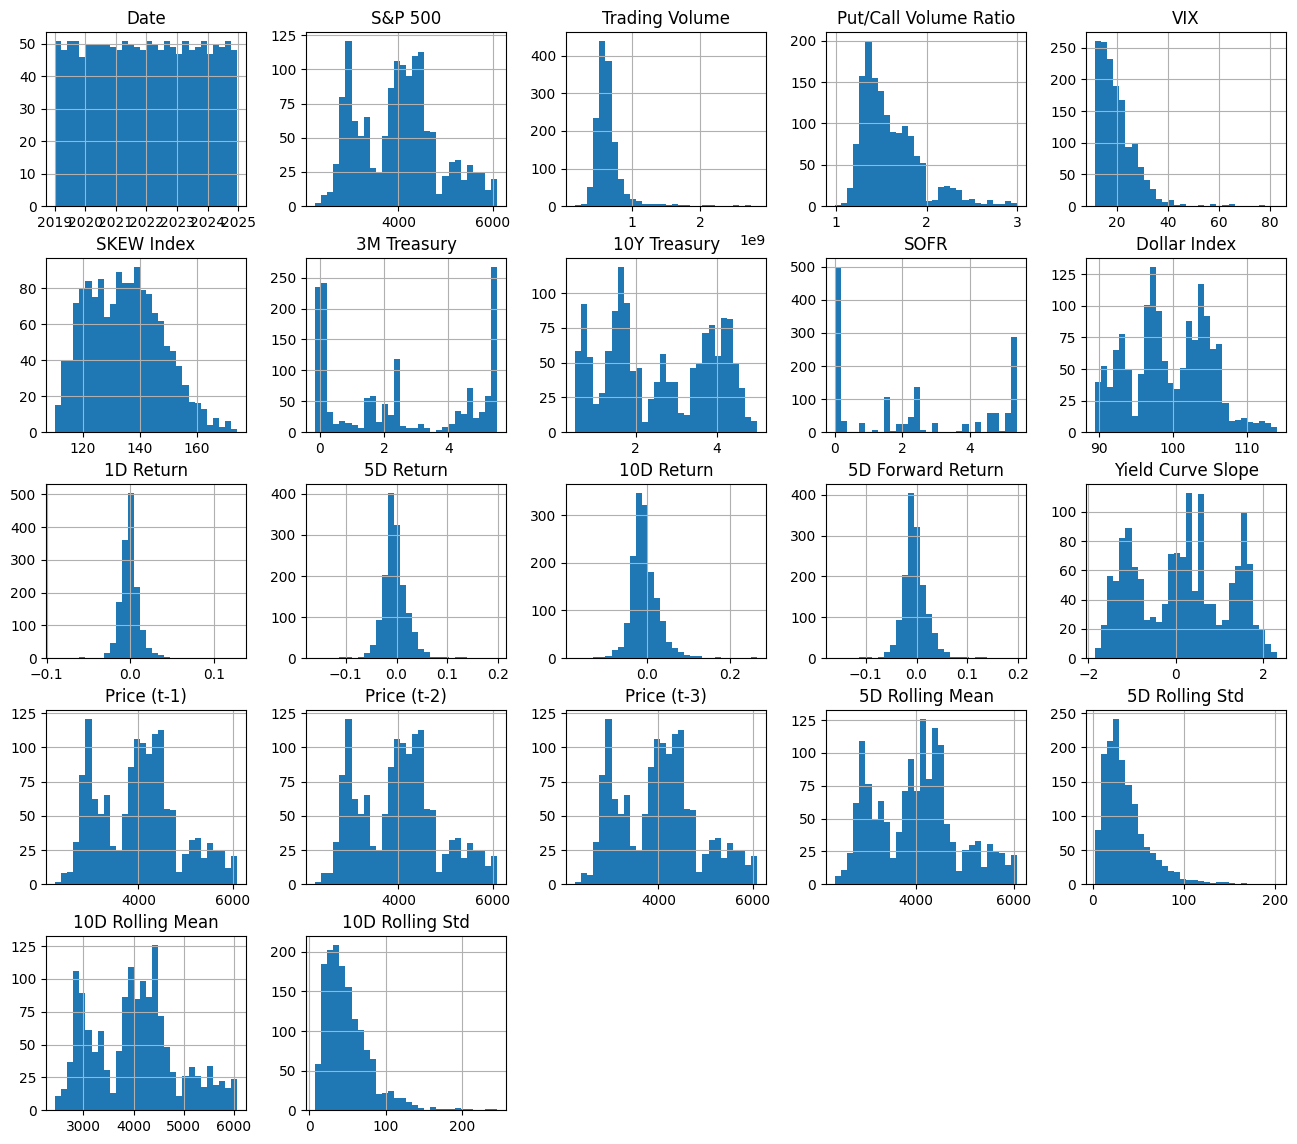

In [26]:
# Distribution

df_plot.hist(figsize=(16, 14), bins=30)

plt.savefig("distribution.pdf", bbox_inches='tight')
plt.show()


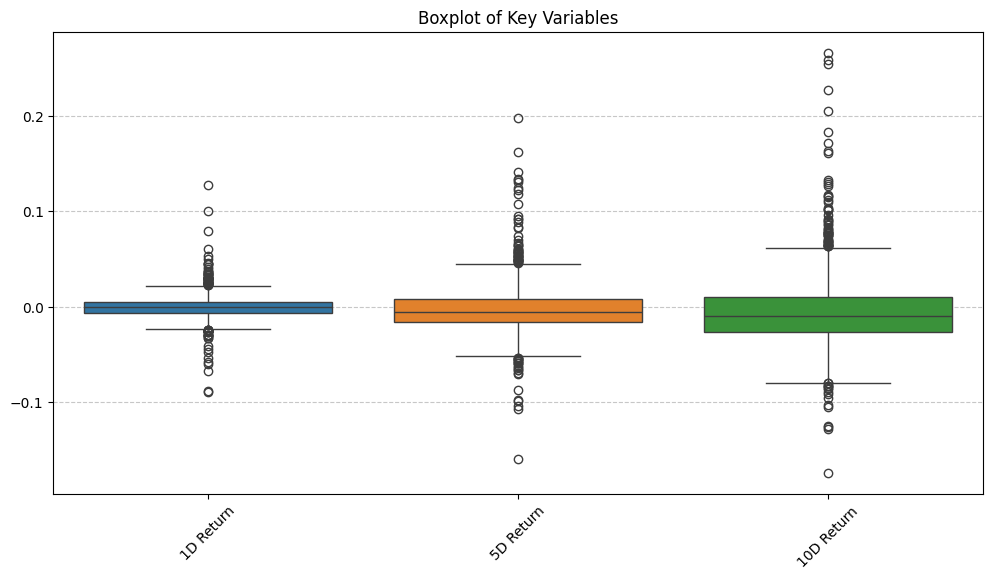

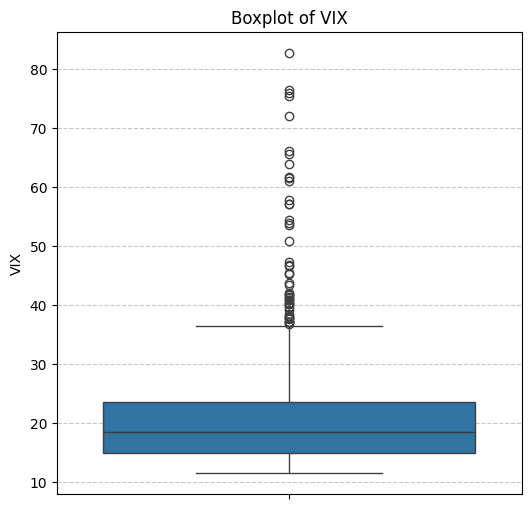

In [27]:
# Boxplot

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['ret_1d','ret_5d','ret_10d']].rename(columns=feature_names))
plt.xticks(rotation=45)
plt.title("Boxplot of Key Variables")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("boxplot.pdf", bbox_inches='tight')

plt.figure(figsize=(6, 6))
sns.boxplot(y=df['lastp_vix'])

plt.title("Boxplot of VIX")
plt.ylabel(feature_names['lastp_vix'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig("boxplot_VIX.pdf", bbox_inches='tight')
plt.show()


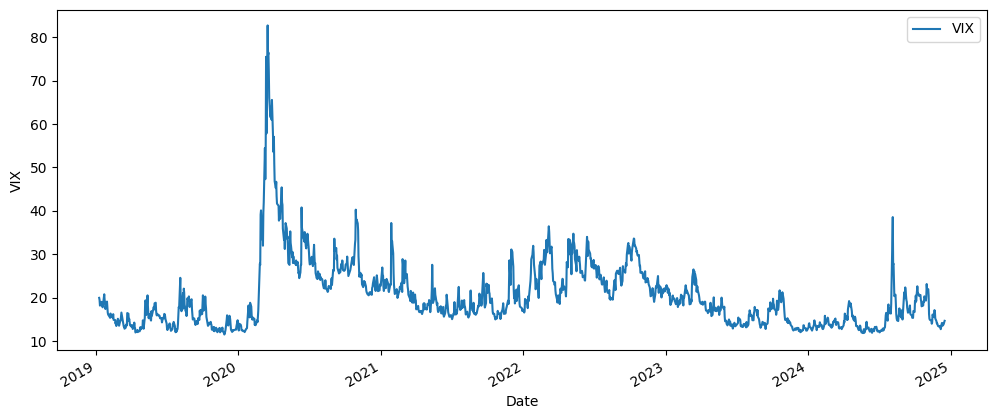

In [28]:
#Volatility
df_plot.set_index('Date', inplace=True)

df_plot[['VIX']].plot(figsize=(12,5))
plt.xlabel("Date")
plt.ylabel("VIX")

plt.savefig("volatility.pdf", bbox_inches='tight')
plt.show()


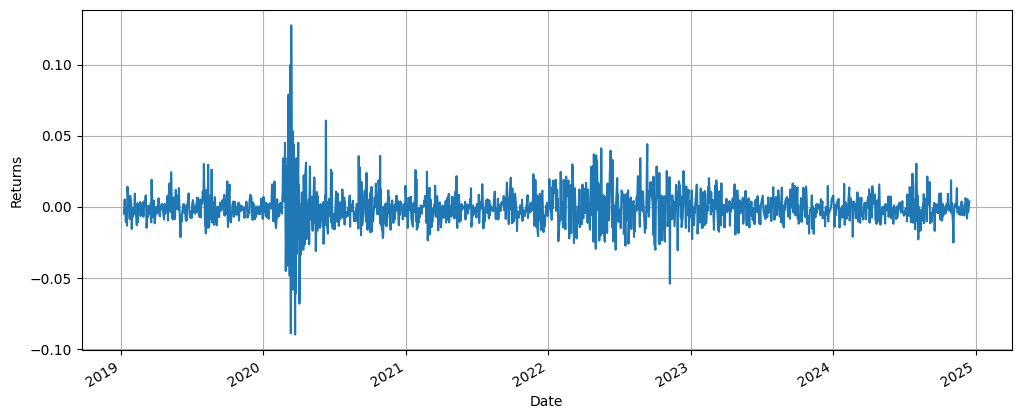

In [29]:
#Daily returns over time
df_plot['1D Return'].plot(figsize=(12,5))

plt.xlabel("Date")
plt.ylabel("Returns")

plt.grid(True)
plt.savefig("returns.pdf", bbox_inches='tight')
plt.show()

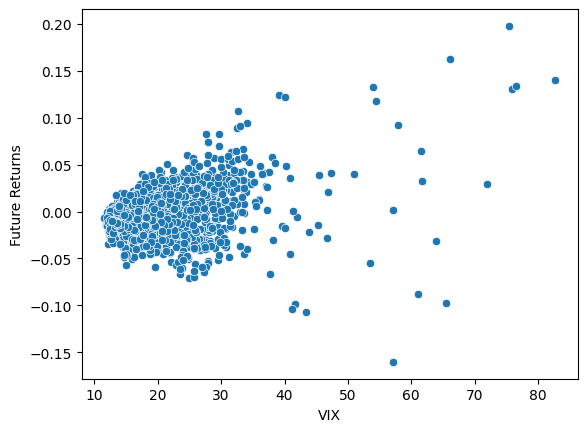

In [30]:
#VIX vs 5-Day Forward Returns

sns.scatterplot(
    x=df['lastp_vix'],
    y=df['ret_5d_fwd']
)
plt.xlabel("VIX")
plt.ylabel("Future Returns")

plt.savefig("vix_vs_returns.pdf", bbox_inches='tight')
plt.show()

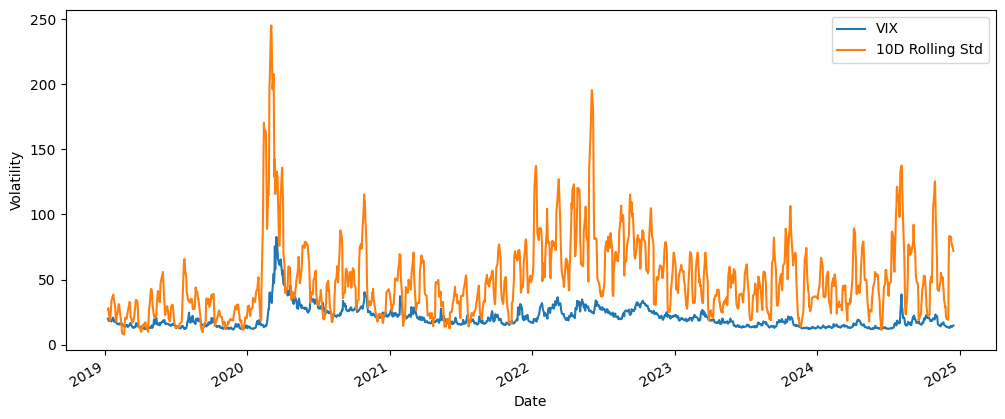

In [31]:
# VIX vs Rolling Volatility
df_plot[['VIX','10D Rolling Std']].plot(figsize=(12,5))

plt.xlabel("Date")
plt.ylabel("Volatility")

plt.savefig("vol_comparison.pdf", bbox_inches='tight')
plt.show()

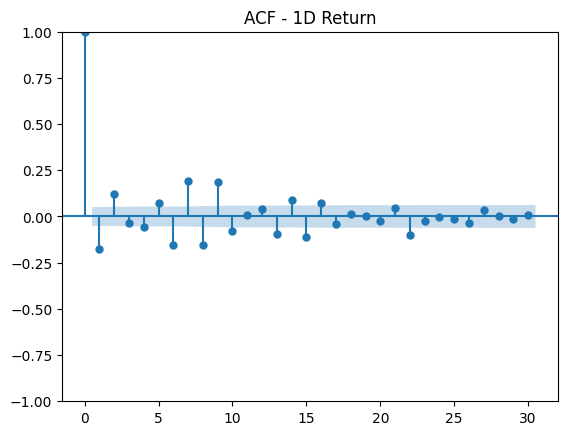

In [32]:
# Autocorrelation

plot_acf(df['ret_1d'].dropna(), lags=30)
plt.title(f"ACF - {feature_names['ret_1d']}")
plt.savefig("ACF.pdf", bbox_inches='tight')
plt.show()


In [33]:
# Stationarity

result = adfuller(df['ret_1d'].dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -11.60595807608778
p-value: 2.5808379248812916e-21


In [34]:
# Summary

df_numeric = df_plot.select_dtypes(include=['number'])

summary = df_numeric.describe().T
summary['skewness'] = df_numeric.skew()
summary['kurtosis'] = df_numeric.kurtosis()

summary = summary.round(4)

latex_table = summary.to_latex(float_format="%.4f")

summary

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
S&P 500,1482.0,4.025198e+03,8.487340e+02,2.237400e+03,3.275030e+03,4.076585e+03,4.509087e+03,6.090270e+03,0.2714,-0.5462
Trading Volume,1482.0,6.630162e+08,2.533086e+08,1.707938e+08,5.414611e+08,6.158345e+08,7.010168e+08,2.834896e+09,4.1137,23.6187
Put/Call Volume Ratio,1482.0,1.607100e+00,3.308000e-01,9.900000e-01,1.370000e+00,1.520000e+00,1.770000e+00,3.000000e+00,1.3682,2.1052
VIX,1482.0,2.042640e+01,7.986500e+00,1.154000e+01,1.491000e+01,1.857500e+01,2.353000e+01,8.269000e+01,2.6389,12.0963
SKEW Index,1482.0,1.347302e+02,1.281260e+01,1.103400e+02,1.239425e+02,1.343850e+02,1.437650e+02,1.739300e+02,0.3111,-0.5171
3M Treasury,1482.0,2.435500e+00,2.159200e+00,-1.372000e-01,9.390000e-02,2.080600e+00,4.803300e+00,5.507000e+00,0.2293,-1.5922
10Y Treasury,1482.0,2.576200e+00,1.296200e+00,5.069000e-01,1.517000e+00,2.499000e+00,3.835100e+00,4.989800e+00,0.0724,-1.4153
SOFR,1482.0,2.378200e+00,2.139900e+00,1.000000e-02,8.000000e-02,2.205000e+00,4.830000e+00,5.400000e+00,0.2400,-1.5753
Dollar Index,1482.0,9.950100e+01,5.337000e+00,8.943600e+01,9.594350e+01,9.900000e+01,1.039215e+02,1.141060e+02,0.0746,-0.7454
1D Return,1482.0,-6.000000e-04,1.270000e-02,-8.970000e-02,-6.900000e-03,-9.000000e-04,4.600000e-03,1.277000e-01,0.8664,15.4518


In [35]:
latex_table

'\\begin{tabular}{lrrrrrrrrrr}\n\\toprule\n & count & mean & std & min & 25% & 50% & 75% & max & skewness & kurtosis \\\\\n\\midrule\nS&P 500 & 1482.0000 & 4025.1984 & 848.7340 & 2237.4000 & 3275.0300 & 4076.5850 & 4509.0875 & 6090.2700 & 0.2714 & -0.5462 \\\\\nTrading Volume & 1482.0000 & 663016198.0135 & 253308637.6579 & 170793792.0000 & 541461120.0000 & 615834496.0000 & 701016816.0000 & 2834896128.0000 & 4.1137 & 23.6187 \\\\\nPut/Call Volume Ratio & 1482.0000 & 1.6071 & 0.3308 & 0.9900 & 1.3700 & 1.5200 & 1.7700 & 3.0000 & 1.3682 & 2.1052 \\\\\nVIX & 1482.0000 & 20.4264 & 7.9865 & 11.5400 & 14.9100 & 18.5750 & 23.5300 & 82.6900 & 2.6389 & 12.0963 \\\\\nSKEW Index & 1482.0000 & 134.7302 & 12.8126 & 110.3400 & 123.9425 & 134.3850 & 143.7650 & 173.9300 & 0.3111 & -0.5171 \\\\\n3M Treasury & 1482.0000 & 2.4355 & 2.1592 & -0.1372 & 0.0939 & 2.0806 & 4.8033 & 5.5070 & 0.2293 & -1.5922 \\\\\n10Y Treasury & 1482.0000 & 2.5762 & 1.2962 & 0.5069 & 1.5170 & 2.4990 & 3.8351 & 4.9898 & 0.0724 &

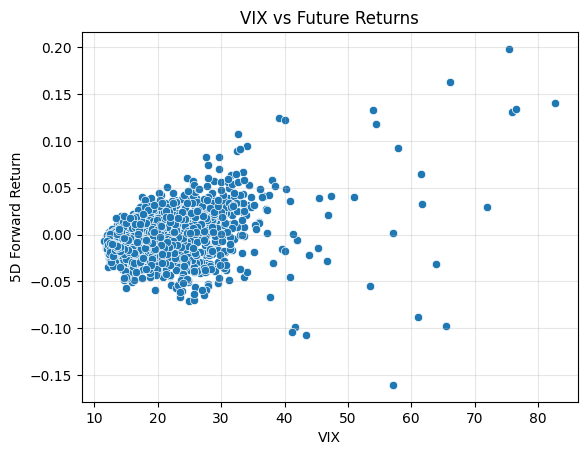

In [36]:
# VIX vs Returns 5d
sns.scatterplot(x=df['lastp_vix'], y=df['ret_5d_fwd'])

plt.title("VIX vs Future Returns")
plt.xlabel(feature_names['lastp_vix'])
plt.ylabel(feature_names['ret_5d_fwd'])

plt.grid(alpha=0.3)
plt.savefig("Vix vs FR.pdf", bbox_inches='tight')
plt.show()


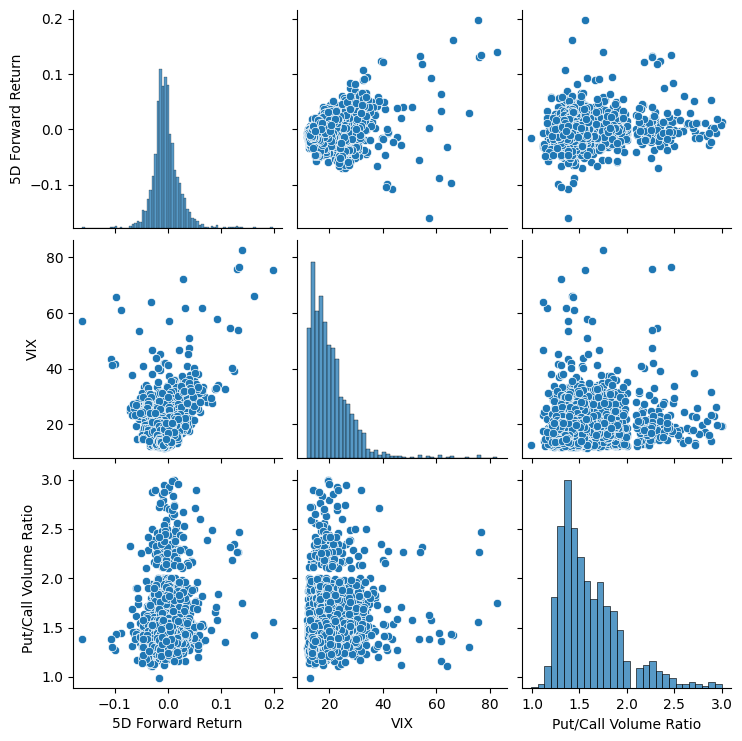

In [37]:
sns.pairplot(df[['ret_5d_fwd','lastp_vix','put_call_volume_sp500']].rename(columns=feature_names))
plt.savefig("scatter.pdf", bbox_inches='tight')

In [38]:
# Correlation

corr_matrix = df_plot.corr(numeric_only=True)
corr_matrix

,S&P 500,Trading Volume,Put/Call Volume Ratio,VIX,SKEW Index,3M Treasury,10Y Treasury,SOFR,Dollar Index,1D Return,...,10D Return,5D Forward Return,Yield Curve Slope,Price (t-1),Price (t-2),Price (t-3),5D Rolling Mean,5D Rolling Std,10D Rolling Mean,10D Rolling Std
S&P 500,1.000000,0.077976,-0.332020,-0.336877,0.676657,0.490111,0.605594,0.487869,0.343802,0.023339,...,0.072681,-0.056647,-0.260386,0.998580,0.997406,0.996066,0.997173,0.071026,0.995265,0.112628
Trading Volume,0.077976,1.000000,-0.133397,0.309105,0.032061,0.070184,0.075315,0.070147,0.142562,-0.011549,...,-0.036673,0.171483,-0.051372,0.078776,0.080593,0.079728,0.080684,0.239769,0.082987,0.222631
Put/Call Volume Ratio,-0.332020,-0.133397,1.000000,0.073730,-0.037482,-0.532181,-0.539808,-0.509896,-0.514840,0.057949,...,0.088521,0.164218,0.428165,-0.334747,-0.337201,-0.337758,-0.338508,-0.047363,-0.340956,-0.082171
VIX,-0.336877,0.309105,0.073730,1.000000,-0.320088,-0.430683,-0.405938,-0.448146,-0.036961,-0.027556,...,-0.104902,0.329660,0.384683,-0.335362,-0.335536,-0.334092,-0.334093,0.511495,-0.330300,0.480728
SKEW Index,0.676657,0.032061,-0.037482,-0.320088,1.000000,0.079781,0.114605,0.105106,-0.185709,0.000962,...,0.017610,-0.116269,-0.022597,0.676813,0.677191,0.676757,0.677487,-0.150324,0.677395,-0.137095
3M Treasury,0.490111,0.070184,-0.532181,-0.430683,0.079781,1.000000,0.936243,0.993751,0.769317,-0.009474,...,-0.022292,-0.025895,-0.900975,0.490757,0.491408,0.492066,0.492557,-0.046350,0.494448,-0.036279
10Y Treasury,0.605594,0.075315,-0.539808,-0.405938,0.114605,0.936243,1.000000,0.915282,0.813888,0.006713,...,0.011290,0.010402,-0.691089,0.605238,0.605045,0.604824,0.605561,0.034053,0.606007,0.051272
SOFR,0.487869,0.070147,-0.509896,-0.448146,0.105106,0.993751,0.915282,1.000000,0.729381,-0.008959,...,-0.021249,-0.025847,-0.914004,0.488589,0.489306,0.489981,0.490479,-0.065411,0.492474,-0.056877
Dollar Index,0.343802,0.142562,-0.514840,-0.036961,-0.185709,0.769317,0.813888,0.729381,1.000000,0.004043,...,0.010943,0.076636,-0.577526,0.343506,0.343201,0.343134,0.343488,0.238150,0.343380,0.263022
1D Return,0.023339,-0.011549,0.057949,-0.027556,0.000962,-0.009474,0.006713,-0.008959,0.004043,1.000000,...,0.352999,-0.034299,0.027777,-0.028416,-0.021607,-0.026189,-0.024597,0.122431,-0.024048,0.139752


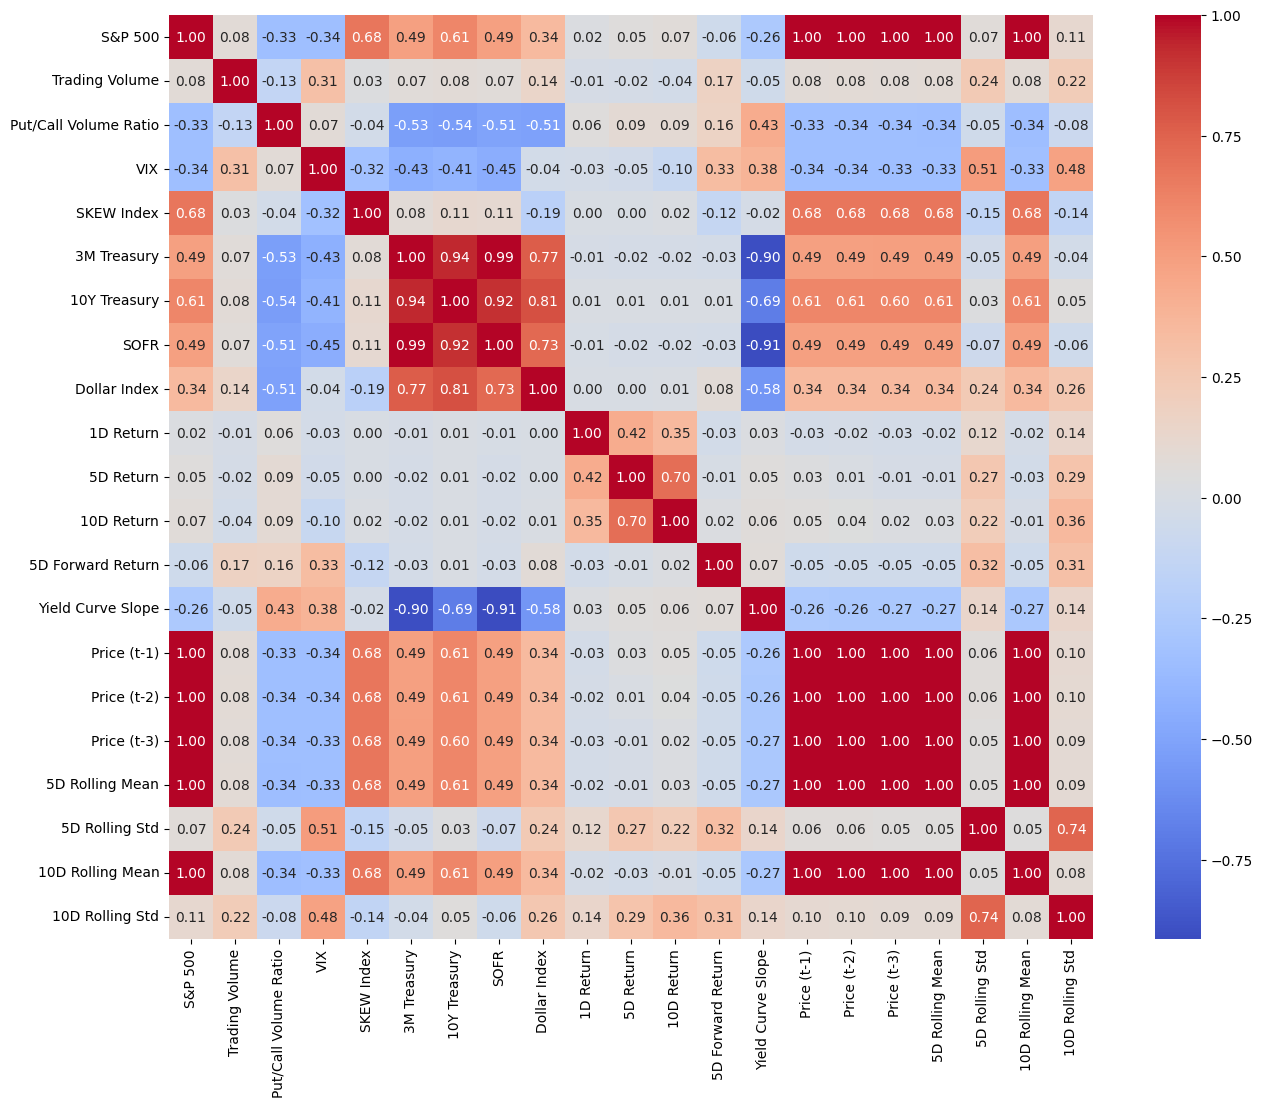

In [39]:
# Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)

plt.savefig("Correlation.pdf", bbox_inches='tight')
plt.show()

In [40]:
# Target correlation
corr_target = corr_matrix['5D Forward Return'].sort_values(ascending=False)
corr_target

5D Forward Return        1.000000
VIX                      0.329660
5D Rolling Std           0.323922
10D Rolling Std          0.308960
Trading Volume           0.171483
Put/Call Volume Ratio    0.164218
Dollar Index             0.076636
Yield Curve Slope        0.066114
10D Return               0.023434
10Y Treasury             0.010402
5D Return               -0.008806
SOFR                    -0.025847
3M Treasury             -0.025895
1D Return               -0.034299
Price (t-2)             -0.053172
Price (t-3)             -0.053203
5D Rolling Mean         -0.053305
Price (t-1)             -0.054736
10D Rolling Mean        -0.054996
S&P 500                 -0.056647
SKEW Index              -0.116269
Name: 5D Forward Return, dtype: float64

In [41]:
# Absolute correlation
corr_abs = corr_matrix.abs()

# Filtering correlations >0.8
high_corr = np.where((corr_abs > 0.8) & (corr_abs < 1))

high_corr_pairs = [
    (corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j])
    for i, j in zip(*high_corr)
]

high_corr_pairs

[('S&P 500', 'Price (t-1)', np.float64(0.9985795278649628)),
 ('S&P 500', 'Price (t-2)', np.float64(0.9974060936116756)),
 ('S&P 500', 'Price (t-3)', np.float64(0.9960658152526783)),
 ('S&P 500', '5D Rolling Mean', np.float64(0.9971728469504708)),
 ('S&P 500', '10D Rolling Mean', np.float64(0.9952651374412488)),
 ('3M Treasury', '10Y Treasury', np.float64(0.9362428046517717)),
 ('3M Treasury', 'SOFR', np.float64(0.9937508370542995)),
 ('3M Treasury', 'Yield Curve Slope', np.float64(-0.9009749629320744)),
 ('10Y Treasury', '3M Treasury', np.float64(0.9362428046517717)),
 ('10Y Treasury', 'SOFR', np.float64(0.9152816069822786)),
 ('10Y Treasury', 'Dollar Index', np.float64(0.8138881884757871)),
 ('SOFR', '3M Treasury', np.float64(0.9937508370542995)),
 ('SOFR', '10Y Treasury', np.float64(0.9152816069822786)),
 ('SOFR', 'Yield Curve Slope', np.float64(-0.9140038652740508)),
 ('Dollar Index', '10Y Treasury', np.float64(0.8138881884757871)),
 ('Yield Curve Slope', '3M Treasury', np.float64(

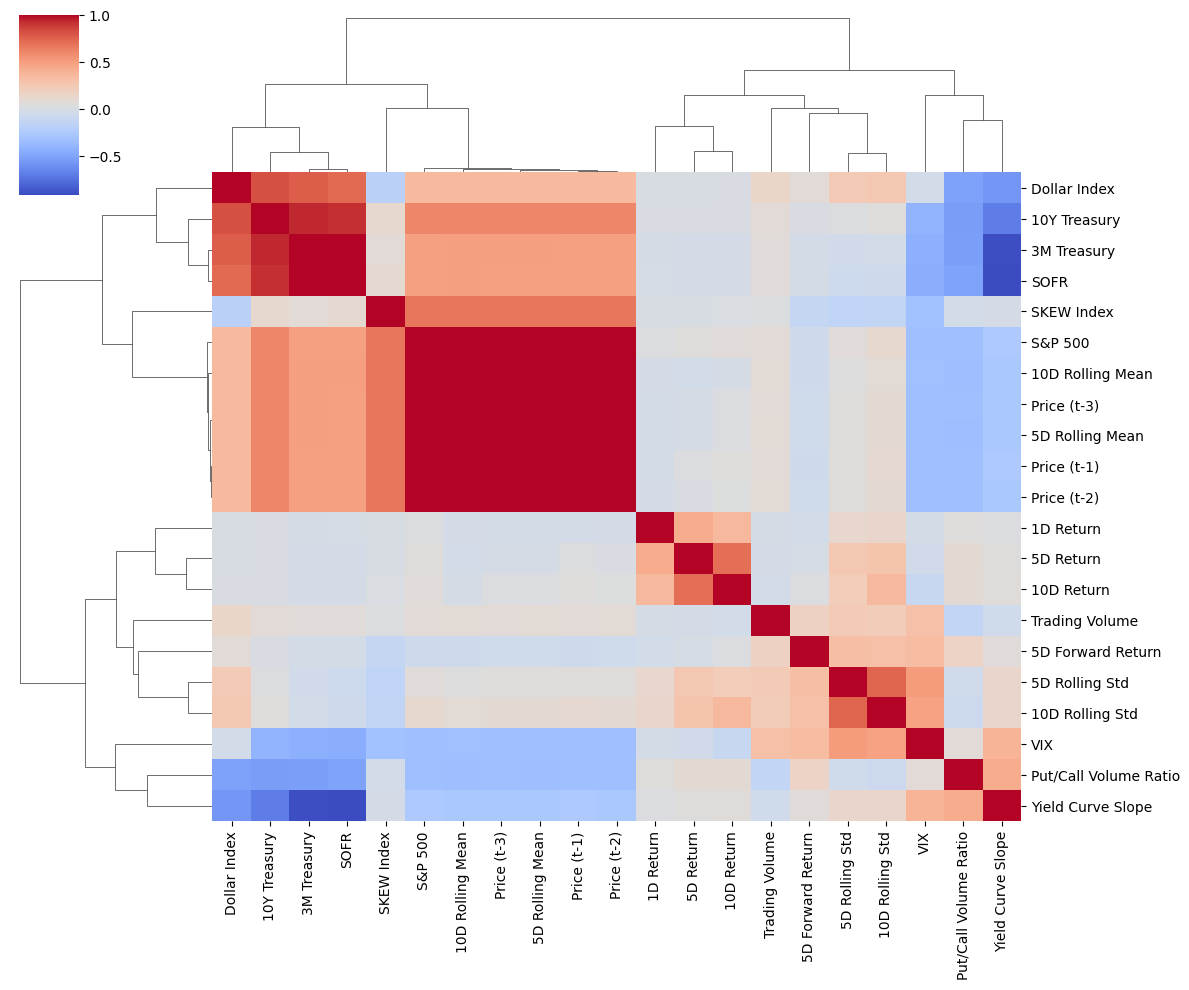

In [42]:
# Cluster map
sns.clustermap(corr_matrix, cmap="coolwarm", figsize=(12, 10))
plt.savefig("cluster_map.pdf", bbox_inches='tight')

## Models

In [92]:
df.head()

,last_price_sp500,volume_sp500,put_call_volume_sp500,iv_30d_sp500,lastp_vix,lastp_skew,lastp_us3m,lastp_us10y,lastp_sofr,lastp_dxy,...,ret_5d_fwd,yield_slope,price_lag1,price_lag2,price_lag3,rolling_mean_5,rolling_std_5,rolling_mean_10,rolling_std_10,garch_vol
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-09,2584.96,629452160.0,1.39,17.38,19.98,117.01,2.4354,2.7100,2.45,95.219,...,-0.029415,0.2746,2596.64,2596.26,2582.61,2600.382,13.155414,2622.251,26.680983,0.016297
2019-01-10,2596.64,625406400.0,1.62,16.76,19.50,117.72,2.4224,2.7421,2.43,95.539,...,-0.058992,0.3197,2596.26,2582.61,2610.30,2608.246,20.216569,2629.063,28.075161,0.014738
2019-01-11,2596.26,543311936.0,1.74,15.50,18.19,119.09,2.4142,2.7007,2.41,95.670,...,-0.025086,0.2865,2582.61,2610.30,2616.10,2623.136,32.727532,2633.822,25.841547,0.013392
2019-01-14,2582.61,601100736.0,1.55,16.32,19.07,125.20,2.4115,2.7024,2.40,95.610,...,-0.012829,0.2909,2610.30,2616.10,2635.96,2633.194,23.619523,2639.561,18.547858,0.012139
2019-01-15,2610.30,597494208.0,1.56,15.16,18.60,126.87,2.4227,2.7112,2.46,96.039,...,-0.013845,0.2885,2616.10,2635.96,2670.71,2638.874,19.851929,2646.636,19.609471,0.011334


In [80]:
# Dataset to Model

df_model = df.copy()
#df_model['Date'] = pd.to_datetime(df['Date'])
#df_model = df_model.sort_values('Date').set_index('Date')

# Optimal Dataset
features = [
    "ret_1d",
    "ret_5d",
    "ret_10d",
    'volume_sp500',
    'put_call_volume_sp500',
    'lastp_vix',
    'lastp_skew',
    'yield_slope'
]

features_benchmark = [
    "ret_1d",
    "ret_5d",
    "ret_10d",
    "price_lag1",
    "price_lag2",
    "price_lag3",
    "rolling_mean_5",
    "rolling_std_5",
    "rolling_mean_10",
    "rolling_std_10"
]

target = 'ret_5d_fwd'

cols_needed = ["Date", target] + sorted(set(features + features_benchmark))

df_model = (
    df.copy()
      .sort_values("Date")[cols_needed]
      .dropna()
      .reset_index(drop=True)
)

X_base = df_model[features_benchmark].copy()
X_ext = df_model[features].copy()
y = df_model[target].copy()

# Time Series split
tscv = TimeSeriesSplit(n_splits = 5)
results = []
predictions = {}
summary_rows = []
full_predictions = {}

KeyError: "['Date'] not in index"

In [105]:
# Model evaluation function
def evaluate_model(name, y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    direction = np.mean(np.sign(y_pred) == np.sign(y_true))

    print(f"--- {name} ---")
    print(f"MAE: {mae:.6f}")
    print(f"MSE: {mse:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R²: {r2:.4f}")
    print(f"Directional Accuracy: {direction:.4f}")
    print()

    return mae, mse, rmse, r2, direction

In [82]:
import numpy as np

def summarize_fold_metrics(model_name, fold_metrics):
    fold_metrics = np.array(fold_metrics)

    mean_metrics = fold_metrics.mean(axis=0)
    std_metrics = fold_metrics.std(axis=0)

    print(f"=== {model_name} - Cross-Validation Summary ===")
    print(f"MAE:  {mean_metrics[0]:.6f} ± {std_metrics[0]:.6f}")
    print(f"MSE:  {mean_metrics[1]:.6f} ± {std_metrics[1]:.6f}")
    print(f"RMSE: {mean_metrics[2]:.6f} ± {std_metrics[2]:.6f}")
    print(f"Directional Accuracy: {mean_metrics[3]:.4f} ± {std_metrics[3]:.4f}")
    print()

    return mean_metrics, std_metrics

In [45]:
# Diebold-Mariano

def diebold_mariano(e1, e2, h=1, power=2):
    e1 = np.asarray(e1)
    e2 = np.asarray(e2)
    
    d = np.abs(e1)**power - np.abs(e2)**power
    mean_d = np.mean(d)

    gamma = [np.cov(d[:-lag], d[lag:])[0,1] for lag in range(1, h)]
    var_d = np.var(d, ddof=1) + 2 * np.sum(gamma)

    dm_stat = mean_d / np.sqrt(var_d / len(d))
    p_value = 2 * (1 - t.cdf(np.abs(dm_stat), df=len(d)-1))

    return dm_stat, p_value
    

In [106]:
# Model 1 - Linear Regression

feature_sets = {
    "Linear Regression - Baseline": X_base,
    "Linear Regression - Market-based": X_ext
}

for model_label, X_current in feature_sets.items():
    lr_pred = np.full(len(y), np.nan)

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X_current), 1):
        X_train, X_test = X_current.iloc[train_idx], X_current.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        lr_model = LinearRegression()
        lr_model.fit(X_train, y_train)
        lr_pred[test_idx] = lr_model.predict(X_test)

    mask = ~np.isnan(lr_pred)
    lr_metrics = evaluate_model(model_label, y[mask], lr_pred[mask])
    predictions[model_label] = (y[mask].values, lr_pred[mask])
    full_predictions[model_label] = lr_pred.copy()
    summary_rows.append([model_label, *lr_metrics])

--- Linear Regression - Baseline ---
MAE: 0.021336
MSE: 0.000908
RMSE: 0.030135
R²: -0.2099
Directional Accuracy: 0.6008

--- Linear Regression - Market-based ---
MAE: 0.024037
MSE: 0.001017
RMSE: 0.031893
R²: -0.3552
Directional Accuracy: 0.5854



In [107]:
# Model 2 - ARIMA
arima_preds = np.full(len(y), np.nan)

for fold, (train_idx, test_idx) in enumerate(tscv.split(y), 1):
    y_train_arima = y.iloc[train_idx]

    arima_model = ARIMA(y_train_arima, order=(1, 0, 0))
    arima_fit = arima_model.fit()

    arima_forecast = arima_fit.forecast(steps=len(test_idx))
    arima_preds[test_idx] = np.asarray(arima_forecast)

mask_arima = ~np.isnan(arima_preds)

model_label = "ARIMA - Benchmark"

arima_metrics = evaluate_model(
    model_label,
    y.iloc[mask_arima],
    arima_preds[mask_arima]
)

predictions[model_label] = (y.iloc[mask_arima].values, arima_preds[mask_arima])
full_predictions[model_label] = arima_preds.copy()
summary_rows.append([model_label, *arima_metrics])

C:\Users\yared\anaconda3\envs\thesis_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\yared\anaconda3\envs\thesis_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\yared\anaconda3\envs\thesis_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\yared\anaconda3\envs\thesis_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer

--- ARIMA - Benchmark ---
MAE: 0.018838
MSE: 0.000755
RMSE: 0.027472
R²: -0.0055
Directional Accuracy: 0.6032



C:\Users\yared\anaconda3\envs\thesis_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\yared\anaconda3\envs\thesis_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [108]:
# Model 3 - GARCH

garch_preds = np.full(len(y), np.nan)
ret1d_series = df_model["ret_1d"].copy()

for fold, (train_idx, test_idx) in enumerate(tscv.split(y), 1):

    for i in test_idx:
        train_series = ret1d_series.iloc[:i].dropna() * 100

        garch_model = arch_model(
            train_series,
            mean="Constant",
            vol="GARCH",
            p=1,
            q=1,
            rescale=False
        )

        garch_fit = garch_model.fit(disp="off")

        garch_forecast = garch_fit.forecast(horizon=5)
        pred_5d = garch_forecast.mean.iloc[-1].values.sum() / 100

        garch_preds[i] = pred_5d

mask_garch = ~np.isnan(garch_preds)

model_label = "GARCH - Benchmark"

garch_metrics = evaluate_model(
    model_label,
    y.iloc[mask_garch],
    garch_preds[mask_garch]
)

predictions[model_label] = (y.iloc[mask_garch].values, garch_preds[mask_garch])
full_predictions[model_label] = garch_preds.copy()
summary_rows.append([model_label, *garch_metrics])

--- GARCH - Benchmark ---
MAE: 0.018710
MSE: 0.000759
RMSE: 0.027551
R²: -0.0114
Directional Accuracy: 0.6032



In [109]:
# Model 4 - Random Forest
fold_boundaries = []
feature_sets = {
    "Random Forest - Baseline": X_base,
    "Random Forest - Market-based": X_ext
}

for model_label, X_current in feature_sets.items():
    rf_preds = np.full(len(y), np.nan)

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X_current), 1):
        X_train, X_test = X_current.iloc[train_idx], X_current.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        rf_model = RandomForestRegressor(
            n_estimators=200,
            max_depth=5,
            random_state=42
        )
        rf_model.fit(X_train, y_train)
        
        rf_pred_fold = rf_model.predict(X_test)
        rf_preds[test_idx] = rf_pred_fold

        fold_boundaries.append({
        "fold": fold,
        "test_start": y_test.index.min(),
        "test_end": y_test.index.max()
        })
        
        if fold == 5:
            X_train_last = X_train.copy()
            X_test_last = X_test.copy()
            y_train_last = y_train.copy()
            y_test_last = y_test.copy()
            y_pred_last = pd.Series(rf_pred_fold, index=y_test.index, name="Prediction")

    mask = ~np.isnan(rf_preds)
    rf_metrics = evaluate_model(model_label, y[mask], rf_preds[mask])
    predictions[model_label] = (y[mask].values, rf_preds[mask])
    full_predictions[model_label] = rf_preds.copy()
    summary_rows.append([model_label, *rf_metrics])

--- Random Forest - Baseline ---
MAE: 0.018269
MSE: 0.000733
RMSE: 0.027078
R²: 0.0231
Directional Accuracy: 0.6291

--- Random Forest - Market-based ---
MAE: 0.018161
MSE: 0.000698
RMSE: 0.026424
R²: 0.0697
Directional Accuracy: 0.6186



In [84]:
# Model 4 - Random Forest AVERAGE
fold_boundaries = []
summary_std_rows = []
feature_sets = {
    "Random Forest - Baseline": X_base,
    "Random Forest - Market-based": X_ext
}
for model_label, X_current in feature_sets.items():
    rf_preds = np.full(len(y), np.nan)
    fold_metrics = []  # Lista para almacenar métricas por fold

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X_current), 1):
        X_train, X_test = X_current.iloc[train_idx], X_current.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        rf_model = RandomForestRegressor(
            n_estimators=200,
            max_depth=5,
            random_state=42
        )
        rf_model.fit(X_train, y_train)

        rf_pred_fold = rf_model.predict(X_test)
        rf_preds[test_idx] = rf_pred_fold

        # Evaluación por fold
        metrics = evaluate_model(
            f"{model_label} - Fold {fold}",
            y_test,
            rf_pred_fold
        )
        fold_metrics.append(metrics)

        # Guardar información del último fold para SHAP y gráficas
        if fold == tscv.n_splits:
            X_train_last = X_train.copy()
            X_test_last = X_test.copy()
            y_train_last = y_train.copy()
            y_test_last = y_test.copy()
            y_pred_last = pd.Series(rf_pred_fold, index=y_test.index, name="Prediction")

    # 📊 Promedio de métricas de los folds
    mean_metrics, std_metrics = summarize_fold_metrics(model_label, fold_metrics)

    # Guardar resultados para tablas finales
    summary_rows.append([
        model_label,
        *mean_metrics
    ])

    # Opcional: guardar desviaciones estándar
    summary_std_rows.append([
        model_label,
        *std_metrics
    ])

--- Random Forest - Baseline - Fold 1 ---
MAE: 0.027579
MSE: 0.001767
RMSE: 0.042039
Directional Accuracy: 0.6194

--- Random Forest - Baseline - Fold 2 ---
MAE: 0.012035
MSE: 0.000233
RMSE: 0.015259
Directional Accuracy: 0.6518

--- Random Forest - Baseline - Fold 3 ---
MAE: 0.026522
MSE: 0.001106
RMSE: 0.033262
Directional Accuracy: 0.5425

--- Random Forest - Baseline - Fold 4 ---
MAE: 0.014236
MSE: 0.000335
RMSE: 0.018306
Directional Accuracy: 0.5870

--- Random Forest - Baseline - Fold 5 ---
MAE: 0.010971
MSE: 0.000225
RMSE: 0.014987
Directional Accuracy: 0.7449

=== Random Forest - Baseline - Cross-Validation Summary ===
MAE:  0.018269 ± 0.007255
MSE:  0.000733 ± 0.000613
RMSE: 0.024771 ± 0.010939
Directional Accuracy: 0.6291 ± 0.0683

--- Random Forest - Market-based - Fold 1 ---
MAE: 0.025721
MSE: 0.001574
RMSE: 0.039675
Directional Accuracy: 0.6154

--- Random Forest - Market-based - Fold 2 ---
MAE: 0.011755
MSE: 0.000226
RMSE: 0.015021
Directional Accuracy: 0.6478

--- Random

In [69]:
fold_boundaries


[{'fold': 1, 'test_start': 247, 'test_end': 493},
 {'fold': 2, 'test_start': 494, 'test_end': 740},
 {'fold': 3, 'test_start': 741, 'test_end': 987},
 {'fold': 4, 'test_start': 988, 'test_end': 1234},
 {'fold': 5, 'test_start': 1235, 'test_end': 1481},
 {'fold': 1, 'test_start': 247, 'test_end': 493},
 {'fold': 2, 'test_start': 494, 'test_end': 740},
 {'fold': 3, 'test_start': 741, 'test_end': 987},
 {'fold': 4, 'test_start': 988, 'test_end': 1234},
 {'fold': 5, 'test_start': 1235, 'test_end': 1481}]

In [76]:
if fold == tscv.n_splits:  # Más robusto que usar fold == 5
    X_train_last = X_train.copy()
    X_test_last = X_test.copy()
    y_train_last = y_train.copy()
    y_test_last = y_test.copy()
    y_pred_last = pd.Series(rf_pred_fold, index=y_test.index, name="Prediction")

    last_fold_info = {
        "train_start": y_train.index.min(),
        "train_end": y_train.index.max(),
        "test_start": y_test.index.min(),
        "test_end": y_test.index.max()
    }

In [77]:
print("Last Fold - Random Forest")
print(f"Train period: {last_fold_info['train_start']} → {last_fold_info['train_end']}")
print(f"Test period:  {last_fold_info['test_start']} → {last_fold_info['test_end']}")

Last Fold - Random Forest
Train period: 2019-01-09 00:00:00 → 2023-12-18 00:00:00
Test period:  2023-12-19 00:00:00 → 2024-12-16 00:00:00


In [110]:
# Model 5 - XGBoost

feature_sets = {
    "XGBoost - Baseline": X_base,
    "XGBoost - Market-based": X_ext
}

for model_label, X_current in feature_sets.items():
    xgb_preds = np.full(len(y), np.nan)

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X_current), 1):
        X_train, X_test = X_current.iloc[train_idx], X_current.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        xgb_model = xgb.XGBRegressor(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )

        xgb_model.fit(X_train, y_train)
        xgb_preds[test_idx] = xgb_model.predict(X_test)

    mask = ~np.isnan(xgb_preds)
    xgb_metrics = evaluate_model(model_label, y[mask], xgb_preds[mask])
    predictions[model_label] = (y[mask].values, xgb_preds[mask])
    full_predictions[model_label] = xgb_preds.copy()
    summary_rows.append([model_label, *xgb_metrics])

--- XGBoost - Baseline ---
MAE: 0.019147
MSE: 0.000769
RMSE: 0.027730
R²: -0.0245
Directional Accuracy: 0.6275

--- XGBoost - Market-based ---
MAE: 0.018840
MSE: 0.000742
RMSE: 0.027232
R²: 0.0119
Directional Accuracy: 0.6162



summary = pd.DataFrame(
    summary_rows,
    columns=["Model", "MAE", "MSE", "RMSE", "R2", "Directional_Accuracy"]
)

summary

In [111]:
# Predictions 
pred_df = pd.DataFrame({
    "Date": df_model["Date"].values,
    "y_true": y.values,
    "lr_base": full_predictions["Linear Regression - Baseline"],
    "lr_mkt": full_predictions["Linear Regression - Market-based"],
    "rf_base": full_predictions["Random Forest - Baseline"],
    "rf_mkt": full_predictions["Random Forest - Market-based"],
    "xgb_base": full_predictions["XGBoost - Baseline"],
    "xgb_mkt": full_predictions["XGBoost - Market-based"],
    "arima": full_predictions["ARIMA - Benchmark"],
    "garch": full_predictions["GARCH - Benchmark"],
    "vix": df_model["lastp_vix"].values
})

KeyError: 'Date'

In [112]:
common_mask = pred_df.drop(columns=["Date"]).notna().all(axis=1)
pred_df = pred_df.loc[common_mask].reset_index(drop=True)

In [113]:
summary = []

model_columns = {
    "Linear Regression - Baseline": "lr_base",
    "Linear Regression - Market-based": "lr_mkt",
    "Random Forest - Baseline": "rf_base",
    "Random Forest - Market-based": "rf_mkt",
    "XGBoost - Baseline": "xgb_base",
    "XGBoost - Market-based": "xgb_mkt",
    "ARIMA - Benchmark": "arima",
    "GARCH - Benchmark": "garch"
}

for name, col in model_columns.items():
    
    mae, mse, rmse, r2, da, = evaluate_model(
        name,
        pred_df["y_true"],
        pred_df[col]
    )
    
    summary.append([name, mae, mse, rmse, r2, da])

summary_df = pd.DataFrame(
    summary,
    columns=["Model", "MAE", "MSE", "RMSE", "R2", "Directional_Accuracy"]
)

summary_df[["Model_Name", "Feature_Set"]] = summary_df["Model"].str.split(" - ", expand=True)

summary_df = summary_df[
    ["Model_Name", "Feature_Set", "MAE", "MSE", "RMSE", "R2", "Directional_Accuracy"]
]

summary_df

--- Linear Regression - Baseline ---
MAE: 0.021336
MSE: 0.000908
RMSE: 0.030135
R²: -0.2099
Directional Accuracy: 0.6008

--- Linear Regression - Market-based ---
MAE: 0.024037
MSE: 0.001017
RMSE: 0.031893
R²: -0.3552
Directional Accuracy: 0.5854

--- Random Forest - Baseline ---
MAE: 0.018269
MSE: 0.000733
RMSE: 0.027078
R²: 0.0231
Directional Accuracy: 0.6291

--- Random Forest - Market-based ---
MAE: 0.018161
MSE: 0.000698
RMSE: 0.026424
R²: 0.0697
Directional Accuracy: 0.6186

--- XGBoost - Baseline ---
MAE: 0.019147
MSE: 0.000769
RMSE: 0.027730
R²: -0.0245
Directional Accuracy: 0.6275

--- XGBoost - Market-based ---
MAE: 0.018840
MSE: 0.000742
RMSE: 0.027232
R²: 0.0119
Directional Accuracy: 0.6162

--- ARIMA - Benchmark ---
MAE: 0.018838
MSE: 0.000755
RMSE: 0.027472
R²: -0.0055
Directional Accuracy: 0.6032

--- GARCH - Benchmark ---
MAE: 0.018710
MSE: 0.000759
RMSE: 0.027551
R²: -0.0114
Directional Accuracy: 0.6032



,Model_Name,Feature_Set,MAE,MSE,RMSE,R2,Directional_Accuracy
0,Linear Regression,Baseline,0.021336,0.000908,0.030135,-0.209907,0.600810
1,Linear Regression,Market-based,0.024037,0.001017,0.031893,-0.355226,0.585425
2,Random Forest,Baseline,0.018269,0.000733,0.027078,0.023052,0.629150
3,Random Forest,Market-based,0.018161,0.000698,0.026424,0.069681,0.618623
4,XGBoost,Baseline,0.019147,0.000769,0.027730,-0.024500,0.627530
5,XGBoost,Market-based,0.018840,0.000742,0.027232,0.011925,0.616194
6,ARIMA,Benchmark,0.018838,0.000755,0.027472,-0.005514,0.603239
7,GARCH,Benchmark,0.018710,0.000759,0.027551,-0.011371,0.603239


In [99]:
summary_df.head()

,Model_Name,Feature_Set,MAE,MSE,RMSE,Directional_Accuracy
0,Linear Regression,Baseline,0.021336,0.000908,0.030135,0.600810
1,Linear Regression,Market-based,0.024037,0.001017,0.031893,0.585425
2,Random Forest,Baseline,0.018269,0.000733,0.027078,0.629150
3,Random Forest,Market-based,0.018161,0.000698,0.026424,0.618623
4,XGBoost,Baseline,0.019147,0.000769,0.027730,0.627530


In [54]:
pred_df[["xgb_mkt", "arima", "garch"]].head()

,xgb_mkt,arima,garch
0,-0.011866,-0.000174,-0.006911
1,-0.009348,-0.001468,-0.006831
2,-0.013287,-0.002432,-0.006883
3,-0.011884,-0.003150,-0.006995
4,-0.005334,-0.003685,-0.006922


In [55]:
summary_df.to_latex(float_format="%.4f")

'\\begin{tabular}{lllrrrr}\n\\toprule\n & Model_Name & Feature_Set & MAE & MSE & RMSE & Directional_Accuracy \\\\\n\\midrule\n0 & Linear Regression & Baseline & 0.0213 & 0.0009 & 0.0301 & 0.6008 \\\\\n1 & Linear Regression & Market-based & 0.0240 & 0.0010 & 0.0319 & 0.5854 \\\\\n2 & Random Forest & Baseline & 0.0183 & 0.0007 & 0.0271 & 0.6291 \\\\\n3 & Random Forest & Market-based & 0.0182 & 0.0007 & 0.0264 & 0.6186 \\\\\n4 & XGBoost & Baseline & 0.0191 & 0.0008 & 0.0277 & 0.6275 \\\\\n5 & XGBoost & Market-based & 0.0188 & 0.0007 & 0.0272 & 0.6162 \\\\\n6 & ARIMA & Benchmark & 0.0188 & 0.0008 & 0.0275 & 0.6032 \\\\\n7 & GARCH & Benchmark & 0.0187 & 0.0008 & 0.0276 & 0.6032 \\\\\n\\bottomrule\n\\end{tabular}\n'

In [56]:
models = {
    "LR - Base": "lr_base",
    "LR - Market": "lr_mkt",
    "RF - Base": "rf_base",
    "RF - Market": "rf_mkt",
    "XGB - Base": "xgb_base",
    "XGB - Market": "xgb_mkt",
    "ARIMA": "arima",
    "GARCH": "garch"
}

dm_results = []

model_names = list(models.keys())

for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        m1 = model_names[i]
        m2 = model_names[j]

        e1 = pred_df["y_true"] - pred_df[models[m1]]
        e2 = pred_df["y_true"] - pred_df[models[m2]]

        # limpiar observaciones no válidas
        mask = (~e1.isna()) & (~e2.isna())
        e1_clean = e1[mask]
        e2_clean = e2[mask]

        # diferencia de pérdidas / errores
        d = e1_clean - e2_clean

        # controles para evitar errores
        if len(d) < 2:
            stat, pval = np.nan, np.nan
            note = "Insufficient observations"
        elif np.isclose(np.var(d, ddof=1), 0):
            stat, pval = np.nan, np.nan
            note = "Zero variance in loss differential"
        else:
            try:
                stat, pval = diebold_mariano(e1_clean, e2_clean)
                note = ""
            except Exception as ex:
                stat, pval = np.nan, np.nan
                note = str(ex)

        dm_results.append([m1, m2, len(d), stat, pval, note])

dm_df = pd.DataFrame(
    dm_results,
    columns=["Model 1", "Model 2", "N", "DM Stat", "p-value", "Note"]
)

dm_df["Significant_5pct"] = dm_df["p-value"] < 0.05
dm_df["Significant_5pct"] = dm_df["p-value"] < 0.05

dm_df

,Model 1,Model 2,N,DM Stat,p-value,Note,Significant_5pct
0,LR - Base,LR - Market,1235,-2.263328,0.023789,,True
1,LR - Base,RF - Base,1235,3.119182,0.001856,,True
2,LR - Base,RF - Market,1235,3.338613,0.000867,,True
3,LR - Base,XGB - Base,1235,2.338165,0.019538,,True
4,LR - Base,XGB - Market,1235,2.698693,0.007056,,True
5,LR - Base,ARIMA,1235,2.350984,0.018880,,True
6,LR - Base,GARCH,1235,2.230121,0.025919,,True
7,LR - Market,RF - Base,1235,4.715739,0.000003,,True
8,LR - Market,RF - Market,1235,4.566525,0.000005,,True
9,LR - Market,XGB - Base,1235,3.829546,0.000135,,True


In [57]:
models = {
    "LR - Base": "lr_base",
    "LR - Mkt": "lr_mkt",
    
    "RF - Base": "rf_base",
    "RF - Mkt": "rf_mkt",
    
    "XGB - Base": "xgb_base",
    "XGB - Mkt": "xgb_mkt",
    
    "ARIMA": "arima",
    "GARCH": "garch"
}

pairs = [
    ("LR - Base", "LR - Mkt"),
    ("RF - Base", "RF - Mkt"),
    ("XGB - Base", "XGB - Mkt"),
]

pairs = [
    ("LR - Base", "LR - Mkt"),
    ("RF - Base", "RF - Mkt"),
    ("XGB - Base", "XGB - Mkt"),
]

dm_results = []

for m1, m2 in pairs:
    e1 = pred_df["y_true"] - pred_df[models[m1]]
    e2 = pred_df["y_true"] - pred_df[models[m2]]

    stat, pval = diebold_mariano(e1, e2)

    dm_results.append([m1, m2, stat, pval])

dm_df = pd.DataFrame(
    dm_results,
    columns=["Model 1", "Model 2", "DM Stat", "p-value"]
)

dm_df

,Model 1,Model 2,DM Stat,p-value
0,LR - Base,LR - Mkt,-2.263328,0.023789
1,RF - Base,RF - Mkt,1.798400,0.072358
2,XGB - Base,XGB - Mkt,1.090057,0.275901


In [58]:
vix_threshold = pred_df['vix'].median()

pred_df['regime'] = np.where(
    pred_df['vix'] > vix_threshold,
    'High Volatility',
    'Low Volatility'
)

In [59]:
regime_results = []

models = {
    "LR - Base": "lr_base",
    "LR - Market": "lr_mkt",
    "RF - Base": "rf_base",
    "RF - Market": "rf_mkt",
    "XGB - Base": "xgb_base",
    "XGB - Market": "xgb_mkt",
    "ARIMA": "arima",
    "GARCH": "garch"
}

for regime in pred_df["regime"].unique():
    subset = pred_df[pred_df["regime"] == regime]

    for name, col in models.items():
        
        # limpiar NaNs por seguridad
        mask = subset[["y_true", col]].notna().all(axis=1)
        y_true_reg = subset.loc[mask, "y_true"]
        y_pred_reg = subset.loc[mask, col]

        if len(y_true_reg) == 0:
            mae, mse, rmse, da = np.nan, np.nan, np.nan, np.nan
        else:
            mae, mse, rmse, da = evaluate_model(
                f"{name} ({regime})",
                y_true_reg,
                y_pred_reg
            )

        regime_results.append([regime, name, mae, mse, rmse, da])

regime_df = pd.DataFrame(
    regime_results,
    columns=["Regime", "Model", "MAE", "MSE", "RMSE", "Directional_Accuracy"]
)

regime_df

--- LR - Base (Low Volatility) ---
MAE: 0.014638
MSE: 0.000378
RMSE: 0.019443
Directional Accuracy: 0.6882

--- LR - Market (Low Volatility) ---
MAE: 0.018281
MSE: 0.000505
RMSE: 0.022467
Directional Accuracy: 0.7060

--- RF - Base (Low Volatility) ---
MAE: 0.011378
MSE: 0.000225
RMSE: 0.015013
Directional Accuracy: 0.7189

--- RF - Market (Low Volatility) ---
MAE: 0.011580
MSE: 0.000225
RMSE: 0.015014
Directional Accuracy: 0.7027

--- XGB - Base (Low Volatility) ---
MAE: 0.013134
MSE: 0.000278
RMSE: 0.016675
Directional Accuracy: 0.6882

--- XGB - Market (Low Volatility) ---
MAE: 0.012098
MSE: 0.000244
RMSE: 0.015611
Directional Accuracy: 0.6866

--- ARIMA (Low Volatility) ---
MAE: 0.012110
MSE: 0.000245
RMSE: 0.015659
Directional Accuracy: 0.7157

--- GARCH (Low Volatility) ---
MAE: 0.011667
MSE: 0.000230
RMSE: 0.015178
Directional Accuracy: 0.7157

--- LR - Base (High Volatility) ---
MAE: 0.028065
MSE: 0.001441
RMSE: 0.037957
Directional Accuracy: 0.5130

--- LR - Market (High Volat

,Regime,Model,MAE,MSE,RMSE,Directional_Accuracy
0,Low Volatility,LR - Base,0.014638,0.000378,0.019443,0.688207
1,Low Volatility,LR - Market,0.018281,0.000505,0.022467,0.705977
2,Low Volatility,RF - Base,0.011378,0.000225,0.015013,0.718901
3,Low Volatility,RF - Market,0.011580,0.000225,0.015014,0.702746
4,Low Volatility,XGB - Base,0.013134,0.000278,0.016675,0.688207
5,Low Volatility,XGB - Market,0.012098,0.000244,0.015611,0.686591
6,Low Volatility,ARIMA,0.012110,0.000245,0.015659,0.715670
7,Low Volatility,GARCH,0.011667,0.000230,0.015178,0.715670
8,High Volatility,LR - Base,0.028065,0.001441,0.037957,0.512987
9,High Volatility,LR - Market,0.029820,0.001532,0.039141,0.464286


In [60]:
dm_regime_results = []

model_names = list(models.keys())

for regime in pred_df["regime"].unique():
    
    subset = pred_df[pred_df["regime"] == regime]

    for i in range(len(model_names)):
        for j in range(i + 1, len(model_names)):
            
            m1 = model_names[i]
            m2 = model_names[j]

            e1 = subset["y_true"] - subset[models[m1]]
            e2 = subset["y_true"] - subset[models[m2]]

            # limpiar NaNs
            mask = (~e1.isna()) & (~e2.isna())
            e1_clean = e1[mask]
            e2_clean = e2[mask]

            d = e1_clean - e2_clean

            # validaciones importantes
            if len(d) < 2:
                stat, pval = np.nan, np.nan
                note = "Insufficient observations"
            
            elif np.isclose(np.var(d, ddof=1), 0):
                stat, pval = np.nan, np.nan
                note = "Zero variance"
            
            else:
                try:
                    stat, pval = diebold_mariano(e1_clean, e2_clean)
                    note = ""
                except Exception as ex:
                    stat, pval = np.nan, np.nan
                    note = str(ex)

            dm_regime_results.append([regime, m1, m2, len(d), stat, pval, note])

dm_regime_df = pd.DataFrame(
    dm_regime_results,
    columns=["Regime", "Model 1", "Model 2", "N", "DM Stat", "p-value", "Note"]
)

dm_regime_df

,Regime,Model 1,Model 2,N,DM Stat,p-value,Note
0,Low Volatility,LR - Base,LR - Market,619,-3.407094,6.992175e-04,
1,Low Volatility,LR - Base,RF - Base,619,4.834987,1.682457e-06,
2,Low Volatility,LR - Base,RF - Market,619,4.693368,3.311985e-06,
3,Low Volatility,LR - Base,XGB - Base,619,2.964705,3.146502e-03,
4,Low Volatility,LR - Base,XGB - Market,619,4.044302,5.911955e-05,
5,Low Volatility,LR - Base,ARIMA,619,4.015815,6.652861e-05,
6,Low Volatility,LR - Base,GARCH,619,4.519440,7.431394e-06,
7,Low Volatility,LR - Market,RF - Base,619,11.665313,0.000000e+00,
8,Low Volatility,LR - Market,RF - Market,619,11.182510,0.000000e+00,
9,Low Volatility,LR - Market,XGB - Base,619,8.642938,0.000000e+00,


In [61]:
print(summary_df.to_latex(index=False, float_format="%.6f"))
print(dm_df.to_latex(index=False, float_format="%.6f"))
print(regime_df.to_latex(index=False, float_format="%.6f"))

\begin{tabular}{llrrrr}
\toprule
Model_Name & Feature_Set & MAE & MSE & RMSE & Directional_Accuracy \\
\midrule
Linear Regression & Baseline & 0.021336 & 0.000908 & 0.030135 & 0.600810 \\
Linear Regression & Market-based & 0.024037 & 0.001017 & 0.031893 & 0.585425 \\
Random Forest & Baseline & 0.018269 & 0.000733 & 0.027078 & 0.629150 \\
Random Forest & Market-based & 0.018161 & 0.000698 & 0.026424 & 0.618623 \\
XGBoost & Baseline & 0.019147 & 0.000769 & 0.027730 & 0.627530 \\
XGBoost & Market-based & 0.018840 & 0.000742 & 0.027232 & 0.616194 \\
ARIMA & Benchmark & 0.018838 & 0.000755 & 0.027472 & 0.603239 \\
GARCH & Benchmark & 0.018710 & 0.000759 & 0.027551 & 0.603239 \\
\bottomrule
\end{tabular}

\begin{tabular}{llrr}
\toprule
Model 1 & Model 2 & DM Stat & p-value \\
\midrule
LR - Base & LR - Mkt & -2.263328 & 0.023789 \\
RF - Base & RF - Mkt & 1.798400 & 0.072358 \\
XGB - Base & XGB - Mkt & 1.090057 & 0.275901 \\
\bottomrule
\end{tabular}

\begin{tabular}{llrrrr}
\toprule
Regime & 

In [62]:
last_train_idx, last_test_idx = list(tscv.split(X_ext))[-1]

X_train_last = X_ext.iloc[last_train_idx]
X_test_last = X_ext.iloc[last_test_idx]
y_train_last = y.iloc[last_train_idx]

xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_last, y_train_last)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [63]:
x_test_named = X_test_last.copy()
x_test_named.columns = [feature_names.get(col, col) for col in X_test_last.columns]
x_test_named = x_test_named.astype(float)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(x_test_named)

# Bar plot
plt.figure()
shap.plots.bar(shap_values, show=False)
plt.savefig("shap_bar_XGB.pdf", bbox_inches='tight')
plt.close()

# Beeswarm plot
plt.figure()
shap.plots.beeswarm(shap_values, show=False)
plt.savefig("shap_beeswarm_XGB.pdf", bbox_inches='tight')
plt.close()

In [64]:
last_train_idx, last_test_idx = list(tscv.split(X_ext))[-1]

X_train_last = X_ext.iloc[last_train_idx]
X_test_last = X_ext.iloc[last_test_idx]
y_train_last = y.iloc[last_train_idx]

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train_last, y_train_last)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [65]:
x_test_named = X_test_last.copy()
x_test_named.columns = [feature_names.get(col, col) for col in X_test_last.columns]
x_test_named = x_test_named.astype(float)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(x_test_named)

# Bar plot
plt.figure()
shap.plots.bar(shap_values, max_display=10, show=False)
plt.savefig("shap_bar_rf.pdf", bbox_inches='tight')
plt.close()

# Beeswarm plot
plt.figure()
shap.plots.beeswarm(shap_values, show=False)
plt.savefig("shap_beeswarm_rf.pdf", bbox_inches='tight')
plt.close()

In [66]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').set_index('Date')
y = df['ret_5d_fwd']

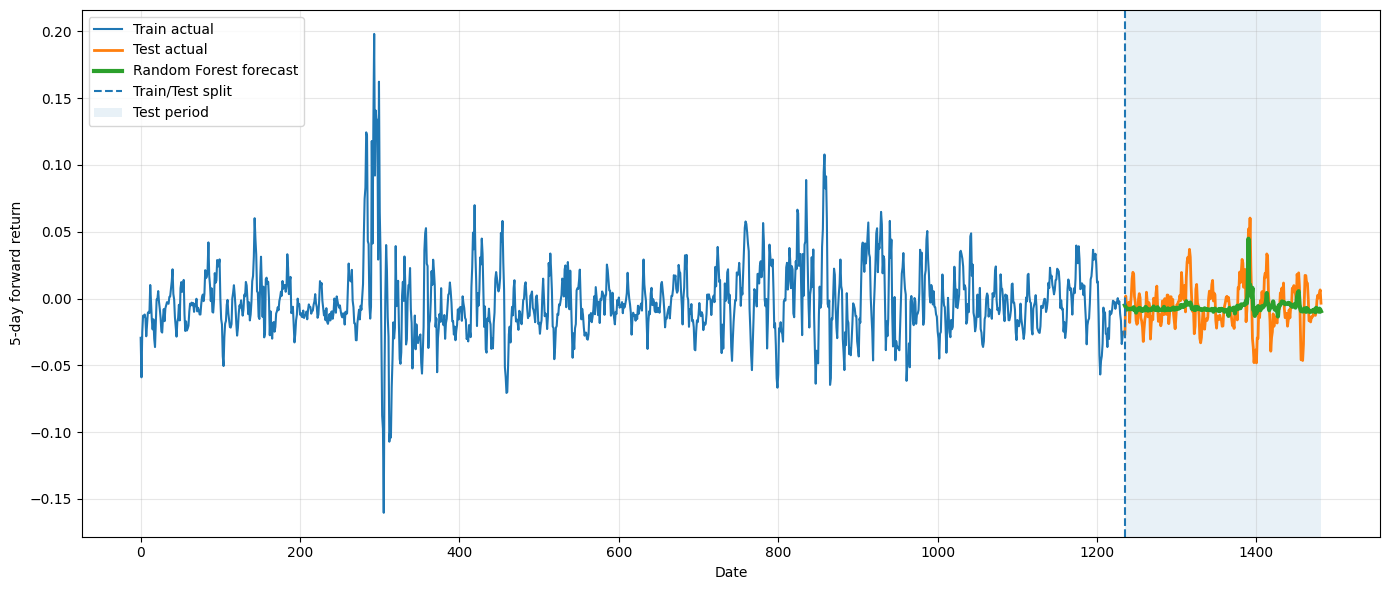

In [67]:
# Graph Final Fold Random Forest
plt.figure(figsize=(14, 6))

plt.plot(y_train_last.index, y_train_last, label='Train actual', linewidth=1.5)
plt.plot(y_test_last.index, y_test_last, label='Test actual', linewidth=2)
plt.plot(y_pred_last.index, y_pred_last, label='Random Forest forecast', linewidth=3)

plt.axvline(y_test_last.index.min(), linestyle='--', linewidth=1.5, label='Train/Test split')

plt.axvspan(y_test_last.index.min(), y_test_last.index.max(), alpha=0.1, label='Test period')

plt.xlabel('Date')
plt.ylabel('5-day forward return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("last_fold_RF.jpg", bbox_inches='tight')
plt.show()

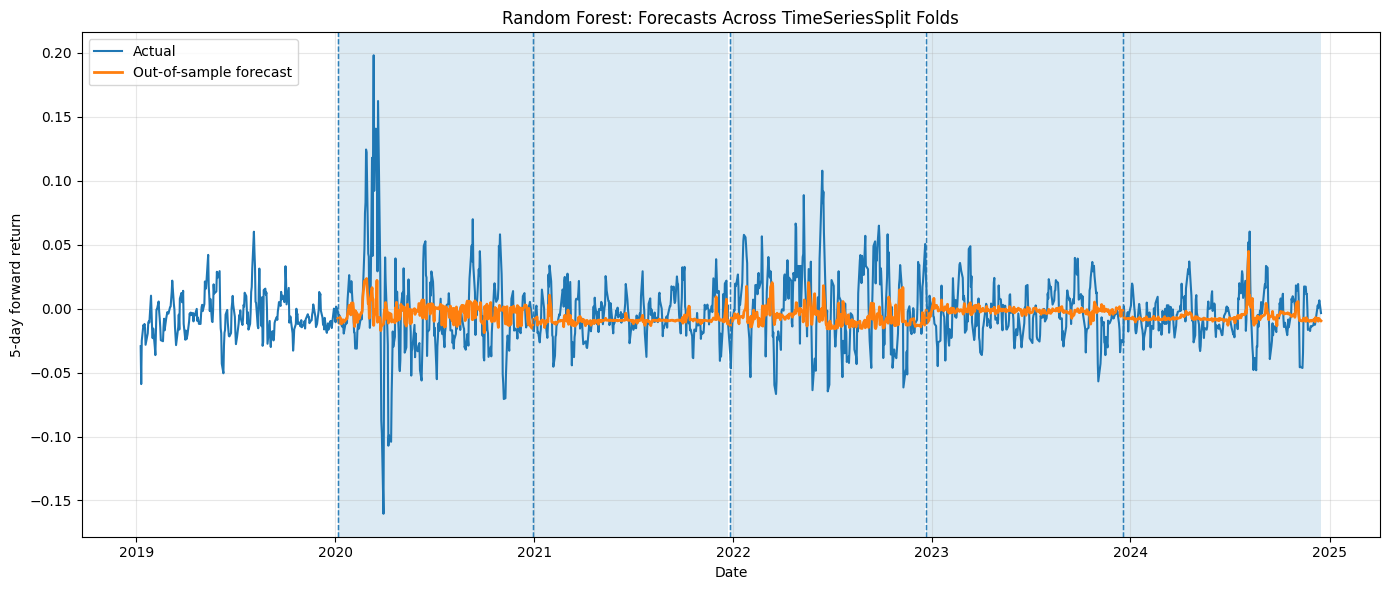

In [85]:
rf_preds_series = pd.Series(rf_preds, index=y.index)
mask = ~np.isnan(rf_preds)

plt.figure(figsize=(14, 6))

plt.plot(y.index, y, label='Actual', linewidth=1.5)
plt.plot(rf_preds_series[mask].index, rf_preds_series[mask], 
         label='Out-of-sample forecast', linewidth=2)

for b in fold_boundaries:
    plt.axvspan(b["test_start"], b["test_end"], alpha=0.08)
    plt.axvline(b["test_start"], linestyle='--', linewidth=1, alpha=0.7)

plt.title('Random Forest: Forecasts Across TimeSeriesSplit Folds')
plt.xlabel('Date')
plt.ylabel('5-day forward return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()